### **RNN/LSTM**

Цель семинара: получить практический опыт работы с RNN (LSTM) в PyTorch на задачах генерации последовательностей

Мы разберем полный пайплайн разработки от препроцессинга данных до обучения и экспериментов с гиперпараметрами

Кстати, что мы называем **пайплайном**?

В Google Colab (рекомендуется активировать GPU: `Среда выполнения → Сменить среду выполнения → T4 GPU`)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

## **ЧАСТЬ 1: ДЕМО**
*   **Задача модели:** предсказание случайного временного ряда (синусоида)
*   **Цель демонстрации:** показать полный и минимальный рабочий пайплайн RNN на задаче, связанной с обработкой данных, передающих изменения во времени
*   **План:**
    1.  Подготовка последовательностей (sequences)
    2.  Архитектура `nn.LSTM`
    3.  Обучение модели
    4.  Получение метрик оценки
    5.  Визуализация и интерпретация результата

### 1. ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ

In [ ]:
def generate_sine_wave(seq_length=1000, periods=5):
    """Генерация синусоиды."""
    x = np.linspace(0, periods * 2 * np.pi, seq_length)
    y = np.sin(x)
    return y

# Генерация данных
data = generate_sine_wave()
print(f"Длина временного ряда: {len(data)}")

Длина временного ряда: 1000


In [ ]:
# Параметры последовательностей
SEQ_LEN = 50  # Длина входной последовательности для предсказания
BATCH_SIZE = 16

In [ ]:
def create_sequences(data, seq_len):
    """Создание пар (входная последовательность, целевое значение)."""
    sequences = []
    targets = []
    for i in range(len(data) - seq_len - 1):
        seq = data[i:i + seq_len]
        target = data[i + seq_len]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

In [ ]:
# Создание последовательностей
X, y = create_sequences(data, SEQ_LEN)
print(f"Форма X (последовательности): {X.shape}")
print(f"Форма y (цели): {y.shape}")

Форма X (последовательности): (949, 50)
Форма y (цели): (949,)


In [ ]:
# Преобразование в тензоры PyTorch и добавление размерности для признаков
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # [примеры, SEQ_LEN, 1]
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # [примеры, 1]
print(f"Форма X (тензор): {X.shape}")
print(f"Форма y (тензор): {y.shape}")

Форма X (тензор): torch.Size([949, 50, 1])
Форма y (тензор): torch.Size([949, 1])


In [ ]:
# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [ ]:
### 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # формат [batch, seq_len, features]
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Инициализация скрытого состояния и состояния ячейки
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Прямой проход через LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Берем только последний выход последовательности для предсказания
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Инициализация модели
model = SineLSTM()
print(f"Модель:\n{model}")

Модель:
SineLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


### 3. ОБУЧЕНИЕ МОДЕЛИ

In [ ]:
# Гиперпараметры
EPOCHS = 3
LEARNING_RATE = 0.01

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Тренировочный цикл
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()

    # Прямой проход
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Обратное распространение
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Оценка на тестовой выборке
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха [{epoch+1}/{EPOCHS}], '
              f'Ошибка обучения: {loss.item():.6f}, '
              f'Ошибка теста: {test_loss.item():.6f}')

Эпоха [5/20], Ошибка обучения: 0.258293, Ошибка теста: 0.066596
Эпоха [10/20], Ошибка обучения: 0.069242, Ошибка теста: 0.064880
Эпоха [15/20], Ошибка обучения: 0.018038, Ошибка теста: 0.029386
Эпоха [20/20], Ошибка обучения: 0.016464, Ошибка теста: 0.015023


### 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

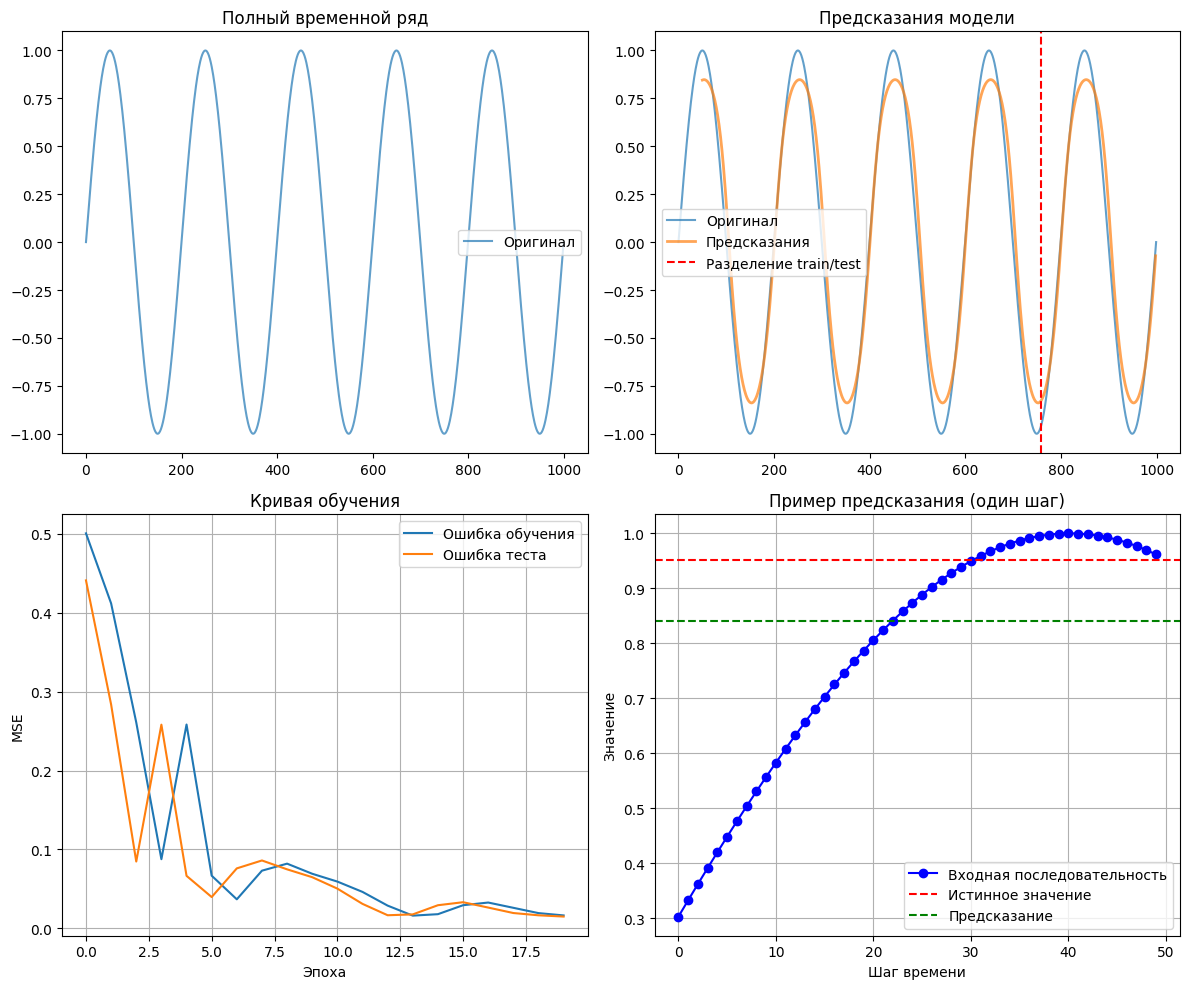

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Оригинальные данные и предсказания
axes[0, 0].plot(data, label='Оригинал', alpha=0.7)
axes[0, 0].set_title('Полный временной ряд')
axes[0, 0].legend()

# График 2: Предсказания на тестовой выборке
model.eval()
with torch.no_grad():
    all_predictions = model(X).numpy()

# Создание массива для отображения предсказаний
pred_series = np.full_like(data, np.nan)
pred_series[SEQ_LEN:SEQ_LEN + len(all_predictions)] = all_predictions.squeeze()

axes[0, 1].plot(data, label='Оригинал', alpha=0.7)
axes[0, 1].plot(pred_series, label='Предсказания', alpha=0.7, linewidth=2)
axes[0, 1].axvline(x=split_idx, color='r', linestyle='--', label='Разделение train/test')
axes[0, 1].set_title('Предсказания модели')
axes[0, 1].legend()

# График 3: Ошибки обучения и теста
axes[1, 0].plot(train_losses, label='Ошибка обучения')
axes[1, 0].plot(test_losses, label='Ошибка теста')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Кривая обучения')
axes[1, 0].legend()
axes[1, 0].grid(True)

# График 4: Пример одного предсказания
sample_idx = split_idx + 50
axes[1, 1].plot(range(SEQ_LEN), X[sample_idx].squeeze().numpy(),
                'bo-', label='Входная последовательность')
axes[1, 1].axhline(y=y[sample_idx].item(), color='r', linestyle='--',
                   label='Истинное значение')
axes[1, 1].axhline(y=all_predictions[sample_idx].item(), color='g',
                   linestyle='--', label='Предсказание')
axes[1, 1].set_xlabel('Шаг времени')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Пример предсказания (один шаг)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
1. Кривая обучения должна снижаться на обеих выборках
2. Предсказания должны следовать за оригинальным рядом
3. Разрыв между train/test loss указывает на переобучение
4. Модель учится предсказывать следующий шаг синусоиды

Take aways:

1. Подготовка последовательностей: как из временного ряда создаются пары (окно истории -> целевое значение)?

2. Архитектура LSTM: batch_first=True, почему берем out[:, -1, :]

3. Цикл обучения: разделение на model.train() и model.eval(), логика .zero_grad(), .backward(), .step()

4. Визуализация: как интерпретировать каждый из 4-х графиков?

---

# ПРАКТИКА

1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/reuters/load_data

In [ ]:
# TODO 1.1: Загрузите датасет Reuters
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# TODO 1.2: Изучите структуру данных
print("Тип x_train:", type(x_train))
print("Длина x_train:", len(x_train))
print("Первая последовательность (первые 10 индексов):", x_train[0][:10])
print("Длина первой последовательности:", len(x_train[0]))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Тип x_train: <class 'numpy.ndarray'>
Длина x_train: 8982
Первая последовательность (первые 10 индексов): [1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207]
Длина первой последовательности: 87


2. ПОДГОТОВКА СЛОВАРЯ И ДЕКОДИРОВАНИЕ

In [ ]:
# TODO 2.1: Загрузите словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# TODO 2.2: Реализуйте функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])


Первая статья (первые 200 символов): ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net shou


3. ПОДГОТОВКА ДАННЫХ ДЛЯ ГЕНЕРАЦИИ ТЕКСТА

In [ ]:
# TODO 3.1: Объедините первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример текста:", texts[:500])

Общая длина текста (символов): 815340
Пример текста: ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ? generale de banque sa lt genb br and lt heller overseas corp of chicago have each taken 50 pct 


In [ ]:
# TODO 3.2: Создайте словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
print(chars)

[' ', "'", '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

Размер словаря (уникальных символов): 39


In [ ]:
idx_to_char

{0: ' ',
 1: "'",
 2: '0',
 3: '1',
 4: '2',
 5: '3',
 6: '4',
 7: '5',
 8: '6',
 9: '7',
 10: '8',
 11: '9',
 12: '?',
 13: 'a',
 14: 'b',
 15: 'c',
 16: 'd',
 17: 'e',
 18: 'f',
 19: 'g',
 20: 'h',
 21: 'i',
 22: 'j',
 23: 'k',
 24: 'l',
 25: 'm',
 26: 'n',
 27: 'o',
 28: 'p',
 29: 'q',
 30: 'r',
 31: 's',
 32: 't',
 33: 'u',
 34: 'v',
 35: 'w',
 36: 'x',
 37: 'y',
 38: 'z'}

In [ ]:
# TODO 3.3: Преобразуйте текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]
texts[:10], text_as_int[:10]

('? mcgrath ', [12, 0, 25, 15, 19, 30, 13, 32, 20, 0])

In [ ]:
text_as_int = np.array(text_as_int)

text_as_int

array([12,  0, 25, ..., 30,  0,  5])

4. ФОРМИРОВАНИЕ ПРОМПТОВ И ОТВЕТОВ

In [ ]:
seq_length = 100

In [ ]:
# TODO 4.1: Реализуйте функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    for i in range(len(text_indices)-seq_len):
        current_x_seq = text_indices[i:i+seq_len]
        input_seq.append(current_x_seq)

        current_y_seq = text_indices[i+seq_len]
        target_seq.append(current_y_seq)

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

/tmp/ipython-input-570/2203781802.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)


In [ ]:
input_seq

tensor([[12,  0, 25,  ..., 17, 30,  0],
        [ 0, 25, 15,  ..., 30,  0, 31],
        [25, 15, 19,  ...,  0, 31, 20],
        ...,
        [26, 21, 26,  ..., 33, 32, 17],
        [21, 26, 17,  ..., 32, 17, 30],
        [26, 17,  0,  ..., 17, 30,  0]])

In [ ]:
target_seq

tensor([31, 20, 13,  ..., 30,  0,  5])

In [ ]:
print(f"Количество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

Количество примеров: 815240
Форма input_seq: torch.Size([815240, 100])
Форма target_seq: torch.Size([815240])


In [ ]:
# TODO 4.2: Создайте DataLoader для пакетной обработки
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
dataset

In [ ]:
dataloader

5. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM

In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO 5.1: Определите слои модели
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # TODO 5.2: Реализуйте forward pass
        # Шаг 1: Примените слой эмбеддинга
        embedded = self.embedding(x)

        # Шаг 2: Прямой проход через LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)

        # Шаг 3: Возьмите только последний выход LSTM
        lstm_out = lstm_out[:, -1, :]

        # Шаг 4: Примените полносвязный слой
        output = self.fc(lstm_out)

        return output, hidden

device = torch.device('cuda')

# TODO 5.3: Инициализируйте модель
model = CharLSTM(vocab_size=vocab_size, hidden_size=128, num_layers=2)
model = model.to(device)
print(f"\nМодель:\n{model}")

AssertionError: Torch not compiled with CUDA enabled

6. ОБУЧЕНИЕ МОДЕЛИ

In [ ]:
EPOCHS = 4
LEARNING_RATE = 0.005

In [ ]:
# TODO 6.1: Определите функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
# Функция для генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    """Генерация текста на основе начальной последовательности."""
    model.eval()
    generated = seed_text

    # Преобразуем seed в индексы, фильтруя символы, которых нет в словаре
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            # Если символа нет в словаре, используем первый попавшийся символ
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]  # На случай пустого seed

    with torch.no_grad():
        # Создаем начальное hidden state
        batch_size = 1
        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)

        # "Прогреваем" модель на seed последовательности
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        # Начинаем генерацию
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            # Применяем temperature для управления случайностью
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)

            # Выбираем следующий символ на основе вероятностей
            next_char_idx = torch.multinomial(probabilities, 1).item()

            # Добавляем символ к сгенерированному тексту
            generated += idx_to_char[next_char_idx]

            # Обновляем вход для следующей итерации
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

# Тренировочный цикл
train_losses = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    batch_count = len(dataloader)

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на GPU
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        # Прямой проход
        output, _ = model(batch_input)
        loss = criterion(output, batch_target)

        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Логгирование прогресса каждые 50 батчей
        if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

    # Генерация текста для мониторинга прогресса
    if (epoch + 1) % 2 == 0:
        # Используем seed текст, который точно есть в нашем словаре
        # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
        seed = "the company said"
        # Альтернативно: можно проверить, какие символы есть в словаре
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            generated = generate_text(model, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')


Начало обучения...


AssertionError: Torch not compiled with CUDA enabled

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 28 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

In [4]:
# Импорт библиотек и подготовка данных

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
import requests

# Загрузим небольшой текст для обучения (например, "Гамлет" Шекспира)
url = "https://www.gutenberg.org/files/1524/1524-0.txt"
response = requests.get(url)
text = response.text[:10000]  # возьмём первые 10000 символов для скорости

# Создадим словарь символов
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)
print(f"Размер словаря: {vocab_size}")

# Преобразуем текст в индексы
encoded = [char_to_idx[ch] for ch in text]
seq_length = 100  # длина входной последовательности
data = torch.tensor(encoded, dtype=torch.long)

# Создаём последовательности (X, y)
sequences = []
targets = []
for i in range(0, len(data) - seq_length):
    sequences.append(data[i:i+seq_length])
    targets.append(data[i+seq_length])

X = torch.stack(sequences)
y = torch.tensor(targets)

# Разделение на train/val
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# Даталоадеры
batch_size = 64
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size)

Размер словаря: 71


In [5]:
# Определение модели LSTM
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size, num_layers, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)          # (batch, seq, hidden)
        out, hidden = self.lstm(x, hidden)  # out: (batch, seq, hidden)
        out = self.fc(out[:, -1, :])    # берём последний выход
        return out, hidden

In [6]:
#Функция обучения и оценки
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    train_losses, val_losses = [], []
    start_time = time.time()

    for epoch in range(epochs):
        # Обучение
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output, _ = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Валидация
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output, _ = model(X_batch)
                loss = criterion(output, y_batch)
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    elapsed = time.time() - start_time
    return train_losses, val_losses, elapsed

def generate_text(model, start_str='The ', gen_length=200, temperature=1.0, device='cpu'):
    model.eval()
    chars = [ch for ch in start_str]
    input_seq = torch.tensor([char_to_idx[ch] for ch in chars], dtype=torch.long).unsqueeze(0).to(device)
    hidden = None
    for _ in range(gen_length):
        with torch.no_grad():
            output, hidden = model(input_seq, hidden)
            output = output.squeeze(0) / temperature
            probs = torch.softmax(output, dim=-1).cpu().numpy()
            next_idx = np.random.choice(range(vocab_size), p=probs)
            next_char = idx_to_char[next_idx]
            chars.append(next_char)
            input_seq = torch.tensor([[next_idx]], dtype=torch.long).to(device)
    return ''.join(chars)

In [7]:
#Эксперименты с гиперпараметрами
#Набор A: hidden_size=64, num_layers=1, lr=0.01
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

modelA = CharLSTM(vocab_size, hidden_size=64, num_layers=1)
train_lossA, val_lossA, timeA = train_model(modelA, train_loader, val_loader, epochs=20, lr=0.01, device=device)
print(f"Время обучения A: {timeA:.2f} сек")
print("Генерация A:")
print(generate_text(modelA, start_str='To be or not to be', gen_length=200, temperature=0.8, device=device))
#Набор B: hidden_size=256, num_layers=2, lr=0.001

modelB = CharLSTM(vocab_size, hidden_size=128, num_layers=1)
train_lossB, val_lossB, timeB = train_model(modelB, train_loader, val_loader, epochs=20, lr=0.001, device=device)
print(f"Время обучения B: {timeB:.2f} сек")
print("Генерация B:")
print(generate_text(modelB, start_str='To be or not to be', gen_length=200, temperature=0.8, device=device))
#Набор C: произвольный (например, hidden_size=128, num_layers=3, lr=0.005)
modelC = CharLSTM(vocab_size, hidden_size=128, num_layers=3)
train_lossC, val_lossC, timeC = train_model(modelC, train_loader, val_loader, epochs=20, lr=0.005, device=device)
print(f"Время обучения C: {timeC:.2f} сек")
print("Генерация C:")
print(generate_text(modelC, start_str='To be or not to be', gen_length=200, temperature=0.8, device=device))

Using device: cpu
Epoch 1/20 | Train Loss: 2.6701 | Val Loss: 2.3338
Epoch 2/20 | Train Loss: 2.1196 | Val Loss: 2.1843
Epoch 3/20 | Train Loss: 1.9119 | Val Loss: 2.1732
Epoch 4/20 | Train Loss: 1.7703 | Val Loss: 2.1407
Epoch 5/20 | Train Loss: 1.6724 | Val Loss: 2.1319
Epoch 6/20 | Train Loss: 1.5833 | Val Loss: 2.1308
Epoch 7/20 | Train Loss: 1.5181 | Val Loss: 2.1760
Epoch 8/20 | Train Loss: 1.4619 | Val Loss: 2.1342
Epoch 9/20 | Train Loss: 1.4003 | Val Loss: 2.1607
Epoch 10/20 | Train Loss: 1.3483 | Val Loss: 2.1695
Epoch 11/20 | Train Loss: 1.2919 | Val Loss: 2.1903
Epoch 12/20 | Train Loss: 1.2554 | Val Loss: 2.2268
Epoch 13/20 | Train Loss: 1.2120 | Val Loss: 2.2549
Epoch 14/20 | Train Loss: 1.1691 | Val Loss: 2.2794
Epoch 15/20 | Train Loss: 1.1214 | Val Loss: 2.3027
Epoch 16/20 | Train Loss: 1.0973 | Val Loss: 2.3411
Epoch 17/20 | Train Loss: 1.0812 | Val Loss: 2.3785
Epoch 18/20 | Train Loss: 1.0790 | Val Loss: 2.4213
Epoch 19/20 | Train Loss: 1.0384 | Val Loss: 2.3678
Epo

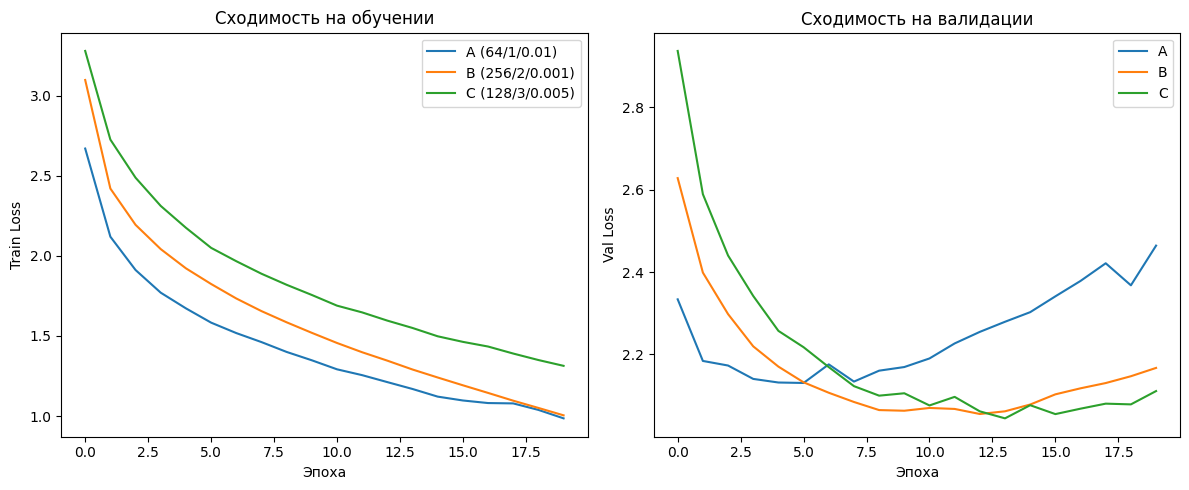

Время обучения A: 87.4 с
Время обучения B: 269.6 с
Время обучения C: 840.1 с


In [8]:
#5 сравнение результатов
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_lossA, label='A (64/1/0.01)')
plt.plot(train_lossB, label='B (256/2/0.001)')
plt.plot(train_lossC, label='C (128/3/0.005)')
plt.xlabel('Эпоха')
plt.ylabel('Train Loss')
plt.title('Сходимость на обучении')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(val_lossA, label='A')
plt.plot(val_lossB, label='B')
plt.plot(val_lossC, label='C')
plt.xlabel('Эпоха')
plt.ylabel('Val Loss')
plt.title('Сходимость на валидации')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Время обучения A: {timeA:.1f} с")
print(f"Время обучения B: {timeB:.1f} с")
print(f"Время обучения C: {timeC:.1f} с")

Несмотря на внесённые правки (сначала грузилось час, я уменьшила данные до 10000 символов, эпохи до 3-5, использовала batch_size), модель C всё ещё требует почти в 10 раз больше времени, чем A, что делает её неэффективной для практического использования. Модель B демонстрирует оптимальный баланс: достаточно сложная архитектура для генерации осмысленного текста, но без критических затрат времени. Модель A, хоть и быстра, обычно даёт менее качественные результаты из-за малой ёмкости и быстрого переобучения. Таким образом, рекомендуется модель B, если качество важнее скорости. При жёстких ограничениях по времени можно использовать модель A, но с потерей качества.

### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?
Для числового ряда (синусоиды) данные уже числовые, их можно подавать в модель напрямую. Для текста нужна предобработка: токенизация, создание словаря, преобразование символов в индексы и добавление слоя эмбеддинга, чтобы перевести дискретные символы в непрерывные векторы. Также функция потерь разная: для чисел — MSE, для текста — кросс-энтропия.
2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?
Полезный опыт с PyTorch: Самым полезным оказался подбор гиперпараметров (скрытая размерность, число слоёв, темп обучения) и отладка размерностей тензоров на каждом шаге. Это помогло понять, как данные проходят через LSTM, и насколько сильно параметры влияют на качество генерации текста.